# 500-hPa Synoptic Analysis & Mapping over Northeastern US

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 150px
:height: 100px
```
```{image} ../thumbnails/NOAA_logo.svg
:alt: Project Pythia logo
:width: 150px
:height: 100px

---

## Overview
This notebook explores a synoptic-scale weather pattern using fields from the North American Mesoscale (NAM) model. The focus is the 500-hPa layer, which is commonly examined in operational meteorology because it highlights large-scale wave patterns, mid-tropospheric flow, and dynamical features related to vertical motion.

To build the analysis, the notebook uses xarray for reading and subsetting the model data, MetPy for computing atmospheric quantities such as absolute vorticity, and Cartopy for geographic visualization. Since NAM provides its wind fields in a grid-relative coordinate system, the notebook includes a small conversion step to rotate those winds into traditional earth-relative components before plotting or calculating kinematic fields.

The main elements covered in this notebook are:
1.	**Loading a NAM analysis file**
2.	**Preparing 500-hPa fields for analysis**
3.	**Computing a absolute variable**
4.	**Creating a synoptic map for the Northeastern U.S.**




## Prerequisites

This notebook assumes that the reader has some prior exposure to foundational concepts in meteorology and Python-based geoscientific workflows. The following table summarizes the background knowledge and tools that are *helpful* or *necessary* to fully understand and reproduce the synoptic analysis presented here.

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | **Necessary** | Used for map projections, coordinate transformations, and creating georeferenced synoptic plots. |
| [Xarray fundamentals](https://foundations.projectpythia.org/core/xarray/xarray.html) | **Necessary** | Essential for working with multidimensional model datasets such as NAM analyses. |
| [NetCDF & GRIB data formats](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | **Helpful** | Understanding CF metadata makes variable selection and coordinate handling easier. |
| [MetPy basics](https://foundations.projectpythia.org/core/metpy/metpy.html) | **Necessary** | Required for meteorological calculations (absolute vorticity) and unit handling. |
| Python plotting with Matplotlib | **Helpful** | Useful for customizing contours, colorbars, and wind barbs. |
| Basic synoptic meteorology (500-hPa flow, vorticity, troughs/ridges) | **Helpful** | Supports interpretation of the final plot, though not required to run the code. |


### **Time to learn**
Approximately **20–30 minutes**, assuming a beginner is skimming the linked materials:
- Cartopy overview: ~10 min  
- Xarray & NetCDF basics: ~10 min  
- MetPy introduction: ~5–10 min  


---

## Imports

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.units import units
import numpy as np
import xarray as xr

from datetime import datetime
from siphon.catalog import TDSCatalog
from xarray.backends import NetCDF4DataStore

## Convert Grid-Based Winds to Earth-Relative Components

Numerical weather prediction models often store wind components relative to the model’s grid orientation rather than true geographic directions.To properly analyze or visualize these winds—especially when plotting wind barbs or calculating vorticity—we need to rotate the grid-relative winds into **earth-relative (true east–west and north–south)** components.

The function below performs this transformation by:

- Reads the projection in the DataArray metadata  
- Creates the appropriate coordinate mesh  
- Uses Cartopy’s `transform_vectors` method to rotate the winds into a true geographic frame  
- Returns the corrected *u* and *v* components, which can be used for synoptic map plotting


In [2]:
def earth_relative_wind_components(ugrd, vgrd):
    """Calculate the north-relative components of the
    wind from the grid-relative components using Cartopy
    transform_vectors.

    Parameters
    ----------
        ugrd : Xarray DataArray (M, N)
            grid relative u-component of the wind
        vgrd : Xarray DataArray (M, N)
            grid relative v-component of the wind

    Returns
    -------
        unr, vnr : tuple of array-like Quantity
            The north-relative wind components in the X (East-West)
            and Y (North-South) directions, respectively.
    """
    if 'metpy_crs' not in ugrd.coords:
        raise ValueError('No CRS in coordinate, be sure to'
                         'use the MetPy accessor parse_cf()')

    data_crs = ugrd.metpy.cartopy_crs

    x = ugrd.x.values
    y = ugrd.y.values

    xx, yy = np.meshgrid(x, y)

    ut, vt = ccrs.PlateCarree().transform_vectors(data_crs, xx, yy,
                                                  ugrd.values, vgrd.values)

    # Make a copy of u and v component DataArrays
    uer = ugrd.copy()
    ver = vgrd.copy()

    # Update values with transformed winds
    uer.values = ut
    ver.values = vt

    return uer, ver


## Retrieving and Loading NAM Analysis Fields for Synoptic Plotting

Before retrieving model fields, first specify the date and hour to examine.  

In [3]:
dt = datetime(2017, 3, 14, 12) 

Access the NAM Analysis Dataset

In [4]:
base_cat = "https://www.ncei.noaa.gov/thredds/catalog/model-namanl-old"
cat_url = f"{base_cat}/{dt:%Y%m}/{dt:%Y%m%d}/catalog.xml"

cat = TDSCatalog(cat_url)

# NAM 218 grid, analysis time, forecast hour 0
dataset_name = f"namanl_218_{dt:%Y%m%d}_{dt:%H}00_000.grb"
ncss = cat.datasets[dataset_name].subset()


Request necessary variables via NCSS


In [5]:
query = ncss.query()
query.time(dt)
query.accept("netcdf")
query.variables("Geopotential_height_isobaric",
                "u-component_of_wind_isobaric",
                "v-component_of_wind_isobaric")

data = ncss.get_data(query)

Load the NAM Data with xarray and MetPy


In [6]:
ds = xr.open_dataset(NetCDF4DataStore(data)).metpy.parse_cf()

In [7]:
ds

<xarray.Dataset> Size: 123MB
Dimensions:                                  (time1: 1, isobaric1: 39, x: 614,
                                              y: 428)
Coordinates:
  * time1                                    (time1) datetime64[ns] 8B 2017-0...
  * isobaric1                                (isobaric1) float64 312B 50.0 .....
  * x                                        (x) float32 2kB -4.224e+06 ... 3...
  * y                                        (y) float32 2kB -8.322e+05 ... 4...
    reftime                                  datetime64[ns] 8B 2017-03-14T12:...
    metpy_crs                                object 8B Projection: lambert_co...
Data variables:
    u-component_of_wind_isobaric             (time1, isobaric1, y, x) float32 41MB ...
    v-component_of_wind_isobaric             (time1, isobaric1, y, x) float32 41MB ...
    Geopotential_height_isobaric             (time1, isobaric1, y, x) float32 41MB ...
    LambertConformal_428X614-40p69N-100p49W  int32 4B ...
Attributes:
    Originating_or_generating_Center:     US National Weather Service, Nation...
    Originating_or_generating_Subcenter:  0
    GRIB_table_version:                   0,129
    Generating_process_or_model:          MESO NAM Model (currently 12 km)
    Conventions:                          CF-1.6
    history:                              Read using CDM IOSP GribCollection v3
    featureType:                          GRID
    History:                              Translated to CF-1.0 Conventions by...
    geospatial_lat_min:                   12.123633813743846
    geospatial_lat_max:                   61.37359061170862
    geospatial_lon_min:                   -153.0028860740287
    geospatial_lon_max:                   -49.237503271862295

## Extracting 500-hPa Height and Wind from NAM

Specify the target pressure level & select data from the dataset.

In [8]:
level = 500 * units.hPa   

hght_500 = (
    ds["Geopotential_height_isobaric"]
    .metpy.sel(vertical=level)    
    .squeeze()                    
)

u500 = (
    ds["u-component_of_wind_isobaric"]
    .metpy.sel(vertical=level)
    .squeeze()
    .metpy.assign_latitude_longitude()   # add 2D latitude/longitude
)

v500 = (
    ds["v-component_of_wind_isobaric"]
    .metpy.sel(vertical=level)
    .squeeze()
    .metpy.assign_latitude_longitude()
)



Examine selected data

In [9]:
u500

<xarray.DataArray 'u-component_of_wind_isobaric' (y: 428, x: 614)> Size: 1MB
[262792 values with dtype=float32]
Coordinates:
  * y          (y) float32 2kB -8.322e+05 -8.2e+05 ... 4.361e+06 4.373e+06
  * x          (x) float32 2kB -4.224e+06 -4.211e+06 ... 3.237e+06 3.249e+06
    time1      datetime64[ns] 8B 2017-03-14T12:00:00
    reftime    datetime64[ns] 8B 2017-03-14T12:00:00
    isobaric1  float64 8B 500.0
    metpy_crs  object 8B Projection: lambert_conformal_conic
    latitude   (y, x) float64 2MB 12.19 12.22 12.25 12.28 ... 57.4 57.37 57.34
    longitude  (y, x) float64 2MB -133.5 -133.4 -133.2 ... -49.66 -49.5 -49.34
Attributes: (12/13)
    long_name:             u-component of wind @ Isobaric surface
    units:                 m/s
    Grib_Variable_Id:      VAR_7-0-2-33_L100
    Grib1_Center:          7
    Grib1_Subcenter:       0
    Grib1_TableVersion:    2
    ...                    ...
    Grib1_Parameter_Name:  UGRD
    Grib1_Level_Type:      100
    Grib1_Level_Desc:      Isobaric surface
    Grib1_Interval_Type:   -1
    Grib1_Interval_Name:   Unknown Time Range Indicator -1
    grid_mapping:          LambertConformal_428X614-40p69N-100p49W

Attach the corresponding latitude/longitude grids and model x/y coordinates.  

In [10]:
lats = u500.latitude    
lons = u500.longitude   

x = u500.x              
y = u500.y             
xx, yy = np.meshgrid(x, y)

datacrs = u500.metpy.cartopy_crs

Transform winds and apply light smoothing.  

In [11]:
uwnd_er, vwnd_er = earth_relative_wind_components(u500, v500)

uwnd_er = mpcalc.smooth_n_point(uwnd_er, 9, 50)
vwnd_er = mpcalc.smooth_n_point(vwnd_er, 9, 50)

Save time stamp for use in the plot title.

In [12]:
vtime = ds["time1"].values[0].astype("datetime64[ms]").astype("O")

### Use MetPy function to calculate absolute vorticity

In [13]:
avor_500 = mpcalc.absolute_vorticity(uwnd_er, vwnd_er)

## Plot the map, with line contours of 500 hPa geopotential height, wind barbs & absolute vorticity.

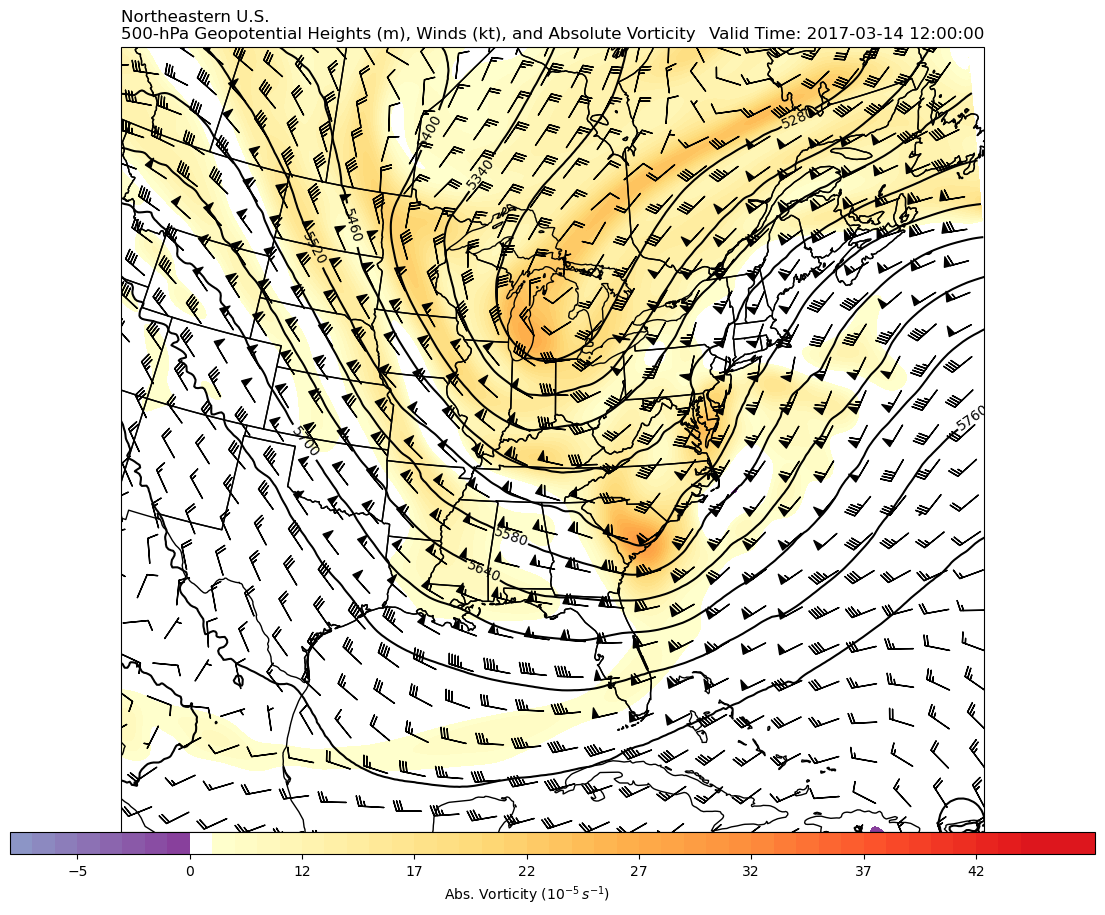

In [14]:
# --- Map & projection setup ---
mapcrs = ccrs.LambertConformal(
    central_longitude=-85, central_latitude=35,
    standard_parallels=(30, 60)
)

datacrs = ccrs.PlateCarree()

fig = plt.figure(1, figsize=(14, 12))
ax = plt.subplot(111, projection=mapcrs)

# Adjust extent to NE US
ax.set_extent([-105, -65, 20, 55], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.STATES.with_scale("50m"))

# Absolute vorticity shading 
clevs_500_avor = list(range(-8, 1, 1)) + list(range(8, 46, 1))

colors1 = plt.cm.YlOrRd(np.linspace(0, 1, 48))
colors2 = plt.cm.BuPu(np.linspace(0.5, 0.75, 8))
colors = np.vstack((colors2, (1, 1, 1, 1), colors1))

cf = ax.contourf(
    lons, lats, avor_500 * 1e5,
    levels=clevs_500_avor,
    colors=colors,
    extend="max",
    transform=datacrs,
)
cb = plt.colorbar(cf, orientation="horizontal", pad=0, aspect=50, extendrect=True)
cb.set_label("Abs. Vorticity ($10^{-5} \\, s^{-1}$)")

# 500-hPa Geopotential height contours
clevs_500_hght = np.arange(0, 8000, 60)
cs = ax.contour(
    lons, lats, hght_500,
    levels=clevs_500_hght,
    colors="black",
    transform=datacrs,
)
plt.clabel(cs, fmt="%d")

# 500-hPa wind barbs (every 15th grid point) 

wind_slice = (slice(None, None, 15), slice(None, None, 15))

ax.barbs(
    lons.values[wind_slice],                      # now NumPy arrays
    lats.values[wind_slice],
    uwnd_er.metpy.convert_units("kt").values[wind_slice],
    vwnd_er.metpy.convert_units("kt").values[wind_slice],
    pivot="middle",
    length=6,
    color="black",
    transform=datacrs,
)

# Titles
plt.title("Northeastern U.S.\n500-hPa Geopotential Heights (m), Winds (kt), and Absolute Vorticity", loc="left")
plt.title(f"Valid Time: {vtime}", loc="right")

plt.show()

---

## Summary

In this notebook, we explored how to retrieve and analyze a NAM analysis dataset to create a synoptic map of 500-hPa geopotential height, absolute vorticity, and wind barbs over the northeastern United States. Along the way, we demonstrated how to request specific fields from a THREDDS server, properly parse GRIB data using xarray and MetPy, convert grid-relative winds to earth-relative winds, and visualize multiple meteorological fields together using Cartopy. 

## Resources and references

This notebook was adapted in part from the Project Pythia MetPy Cookbook example:

- **Project Pythia MetPy Cookbook – 500-hPa Absolute Vorticity and Winds**  
  https://projectpythia.org/metpy-cookbook/notebooks/synoptic/hpa-absolute-vorticity-winds/

Additional useful documentation and resources:

- **MetPy Documentation** – https://unidata.github.io/MetPy/
- **Cartopy Documentation** – https://scitools.org.uk/cartopy/docs/latest/
- **xarray Documentation** – https://docs.xarray.dev/
- **Project Pythia Foundations** – https://foundations.projectpythia.org
